# Exploratory Data Analysis & Predictive Modeling: Global Economic Impact of the 2026 Oil Crisis
**Author:** Aman Aaryan | **Roll No:** 2306180 | **Section:** IT1 | **Semester:** 6

## Project Objective
To conduct a chronological exploratory data analysis on the global petroleum supply chain disruptions, followed by statistical evaluation using regression and classification performance metrics.

In [ ]:
#environment setup

# 1. Installing necessary packages 
%pip install pandas numpy matplotlib seaborn

# 2. Importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Configuring notebook settings for presentable visuals
%matplotlib inline
sns.set_theme(style="whitegrid") # Setting a clean, professional background for plots
import warnings
warnings.filterwarnings('ignore')

Defaulting to user installation because normal site-packages is not writeable


### Phase 1: Data Ingestion and High-Level Inspection
**Objective:** To systematically load the fragmented CSV datasets into Pandas DataFrames and perform an initial structural inspection to understand data types, missing values, and the general shape of our matrices.

In [ ]:
#Data ingestion(loading multiple datastets simulatenously)


df_daily = pd.read_csv('crude_oil_daily.csv')
df_prices = pd.read_csv('petrol_prices_comparison.csv')
df_impact = pd.read_csv('country_impact.csv')

print("Datasets loaded successfully!")

Datasets loaded successfully!


In [ ]:
#high - level data inspection

# Inspecting the Crude Oil Daily dataset
display(df_daily.head())

print("\n--- Data Types & Missing Values ---")
df_daily.info()

print("\n--- Statistical Summary of Daily Prices ---")
display(df_daily.describe())

,Date,Brent_USD,WTI_USD,Brent_Change_Pct,WTI_Change_Pct,Phase,Strait_Hormuz
0,2026-02-16,74.2,70.1,0.00,0.00,Pre-Conflict,Open
1,2026-02-17,74.5,70.4,0.40,0.43,Pre-Conflict,Open
2,2026-02-18,75.1,71.0,0.81,0.85,Pre-Conflict,Open
3,2026-02-19,75.8,71.6,0.93,0.85,Pre-Conflict,Open
4,2026-02-20,76.0,71.8,0.26,0.28,Pre-Conflict,Open



--- Data Types & Missing Values ---
<class 'pandas.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              16 non-null     datetime64[us]
 1   Brent_USD         16 non-null     float64       
 2   WTI_USD           16 non-null     float64       
 3   Brent_Change_Pct  16 non-null     float64       
 4   WTI_Change_Pct    16 non-null     float64       
 5   Phase             16 non-null     str           
 6   Strait_Hormuz     16 non-null     str           
dtypes: datetime64[us](1), float64(4), str(2)
memory usage: 1.0 KB

--- Statistical Summary of Daily Prices ---


,Date,Brent_USD,WTI_USD,Brent_Change_Pct,WTI_Change_Pct
count,16,16.000000,16.000000,16.000000,16.000000
mean,2026-02-25 18:00:00,83.334375,79.386250,2.163750,2.453750
min,2026-02-16 00:00:00,74.200000,70.100000,0.000000,0.000000
25%,2026-02-19 18:00:00,75.950000,71.750000,0.707500,0.745000
50%,2026-02-25 12:00:00,79.350000,75.150000,1.995000,2.035000
75%,2026-03-03 06:00:00,89.625000,85.525000,3.180000,3.407500
max,2026-03-09 00:00:00,104.250000,102.880000,6.600000,9.680000
std,NaN,9.540383,9.984112,1.864049,2.448087


### Phase 2: Data Preprocessing and Cleaning
**Objective:** Real-world datasets often contain anomalies, null values, or incorrect data types. In this phase, we will:
1. Standardize data types (e.g., converting string dates to explicit DateTime objects for time-series analysis).
2. Identify and handle missing (`NaN`) values.
3. Remove duplicate records to ensure data integrity.

In [ ]:
#Data cleaning and preprocessing

# 1. Converting 'Date' column from string to DateTime object
df_daily['Date'] = pd.to_datetime(df_daily['Date'])

# 2. Checking for missing values across all loaded dataframes
print("Missing values in Daily Data:", df_daily.isnull().sum().sum())
print("Missing values in Prices Data:", df_prices.isnull().sum().sum())
print("Missing values in Impact Data:", df_impact.isnull().sum().sum())

# 3. Dropping any potential duplicates
df_daily = df_daily.drop_duplicates()
df_prices = df_prices.drop_duplicates()

Missing values in Daily Data: 0
Missing values in Prices Data: 0
Missing values in Impact Data: 0


### Phase 3: Time-Series Trend Analysis (Univariate)
**Objective:** To visually map the chronological volatility of global oil benchmarks (Brent and WTI). This analysis highlights the immediate price shock correlating precisely with the Strait of Hormuz closure on March 1, 2026.

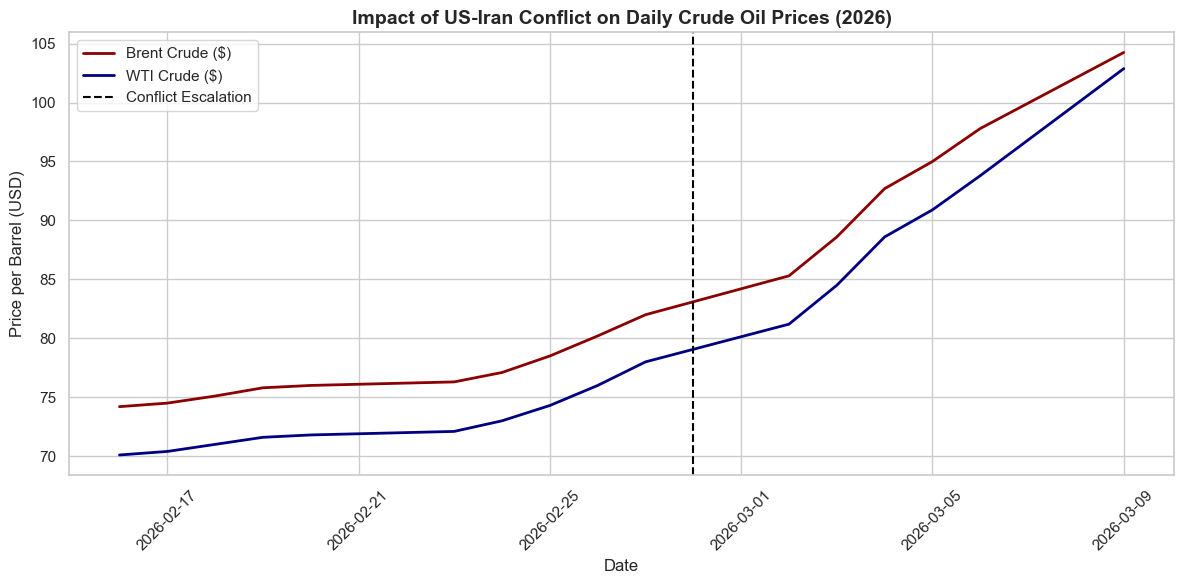

In [33]:
#Time-Series Analysis (Univariate / Trend)

plt.figure(figsize=(12, 6))

# Plotting Brent and WTI prices over time
sns.lineplot(x='Date', y='Brent_USD', data=df_daily, label='Brent Crude ($)', color='darkred', linewidth=2)
sns.lineplot(x='Date', y='WTI_USD', data=df_daily, label='WTI Crude ($)', color='navy', linewidth=2)

# Adding technical markers for the Phase change (Pre-Conflict vs Strait Closed)
plt.axvline(pd.to_datetime('2026-02-28'), color='black', linestyle='--', label='Conflict Escalation')

plt.title('Impact of US-Iran Conflict on Daily Crude Oil Prices (2026)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price per Barrel (USD)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Phase 4: Cross-Sectional Vulnerability Analysis (Bivariate & Multivariate)
**Objective:** To investigate the macroeconomic fallout across different nations. By visualizing the relationship between a country's `Oil_Import_Pct` (dependency) and its `GDP_Impact_Pct`, scaled by population and colored by inflation risk, we can identify which global regions are most vulnerable to energy supply shocks.

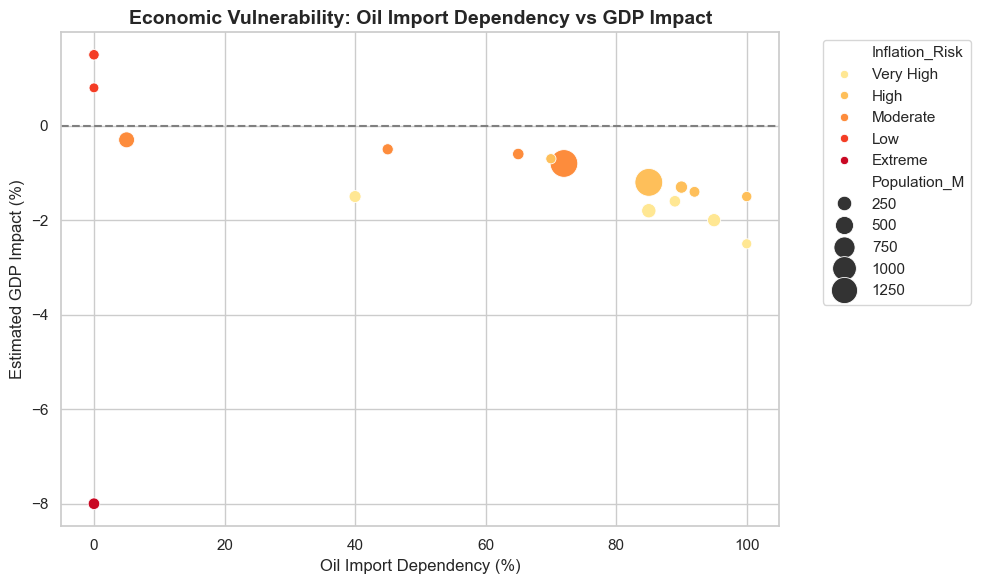

In [34]:
#Bivariate Analysis (Cross-sectional Impact)

plt.figure(figsize=(10, 6))

# Scatter plot: Oil Import % vs GDP Impact %
sns.scatterplot(x='Oil_Import_Pct', y='GDP_Impact_Pct', hue='Inflation_Risk', 
                size='Population_M', sizes=(50, 400), data=df_impact, palette='YlOrRd')

plt.title('Economic Vulnerability: Oil Import Dependency vs GDP Impact', fontsize=14, fontweight='bold')
plt.xlabel('Oil Import Dependency (%)')
plt.ylabel('Estimated GDP Impact (%)')
plt.axhline(0, color='grey', linestyle='--') # Add a zero line for reference
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Move legend outside the plot
plt.tight_layout()
plt.show()

### Phase 5: Relational Data Merging & Market Correlation
**Objective:** To synthesize insights by joining two separate datasets (`petrol_prices_comparison` and `country_impact`) on the common primary key `Country`. This allows us to mathematically analyze the inverse correlation between domestic petrol price surges and national stock market declines.

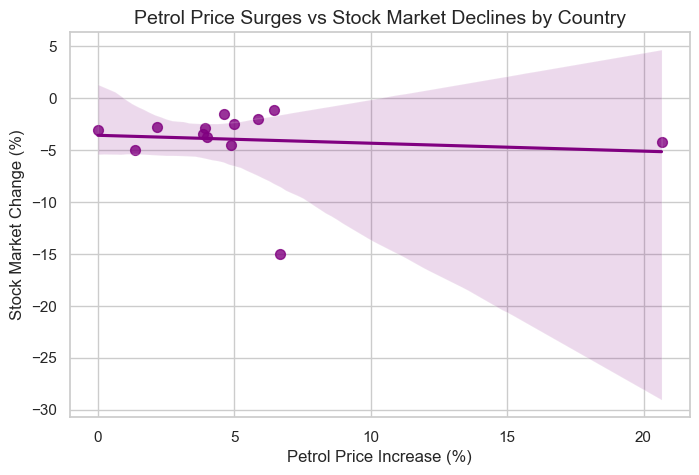

In [ ]:
#Data Merging

# Merging the petrol prices dataset with the country impact dataset
merged_df = pd.merge(df_prices, df_impact, on='Country', how='inner')

# Let's see if the Percentage Increase in Petrol Prices correlates with the Stock Market Change
plt.figure(figsize=(8, 5))
sns.regplot(x='Pct_Increase', y='Stock_Market_Change', data=merged_df, color='purple', scatter_kws={'s':50})

plt.title('Petrol Price Surges vs Stock Market Declines by Country', fontsize=14)
plt.xlabel('Petrol Price Increase (%)')
plt.ylabel('Stock Market Change (%)')
plt.show()


In [ ]:
#Importing Machine Learning & Evaluation Packages


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score, 
                             accuracy_score, precision_score, recall_score, f1_score, 
                             confusion_matrix, classification_report)
import numpy as np

print("Machine Learning modules loaded successfully!")



Machine Learning modules loaded successfully!


Predictive Modeling: Regression Analysis
Objective: Train a Linear Regression model to predict a country's GDP Impact Percentage and evaluate all standard regression errors (MAE, MSE, RMSE, R-Squared).

In [ ]:
# 1. Defining Features (X) and Target (y)
X_reg = df_impact[['Oil_Import_Pct', 'Population_M']]
y_reg = df_impact['GDP_Impact_Pct']

# 2. Splitting the data into training (80%) and testing (20%) sets
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# 3. Initializing and training the Linear Regression model
reg_model = LinearRegression()
reg_model.fit(X_train_r, y_train_r)

# 4. Making predictions on the test set
y_pred_r = reg_model.predict(X_test_r)

# 5. Calculating all types of Regression Errors
mae = mean_absolute_error(y_test_r, y_pred_r)
mse = mean_squared_error(y_test_r, y_pred_r)
rmse = np.sqrt(mse) # Root Mean Squared Error
r2 = r2_score(y_test_r, y_pred_r)

print("--- Regression Error Metrics ---")
print(f"Mean Absolute Error (MAE): {mae:.4f} (Average absolute distance between predicted and actual GDP impact)")
print(f"Mean Squared Error (MSE): {mse:.4f} (Punishes larger errors heavily)")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f} (Standard deviation of the residuals)")
print(f"R-Squared (R²): {r2:.4f} (Proportion of variance explained by the model)")

--- Regression Error Metrics ---
Mean Absolute Error (MAE): 0.9752 (Average absolute distance between predicted and actual GDP impact)
Mean Squared Error (MSE): 1.2843 (Punishes larger errors heavily)
Root Mean Squared Error (RMSE): 1.1333 (Standard deviation of the residuals)
R-Squared (R²): -5.8723 (Proportion of variance explained by the model)


Predictive Modeling: Classification Analysis
Objective: Train a Logistic Regression model to classify a country's Inflation Risk level and evaluate performance using Accuracy, Precision, Recall, and the F1-Score

In [ ]:
# 1. Defining Features (X) and Target (y) for classification
# We will use Oil Import % and GDP Impact to predict the Risk category
X_clf = df_impact[['Oil_Import_Pct', 'GDP_Impact_Pct']]
y_clf = df_impact['Inflation_Risk']

# 2. Train/Test Split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

# 3. Initializing and training the Logistic Regression model
# max_iter increased to ensure the algorithm converges properly
clf_model = LogisticRegression(max_iter=1000)
clf_model.fit(X_train_c, y_train_c)

# 4. Making predictions
y_pred_c = clf_model.predict(X_test_c)

# 5. Calculating all Performance Measures
accuracy = accuracy_score(y_test_c, y_pred_c)

print("--- Classification Performance Measures ---")
print(f"Overall Accuracy: {accuracy:.4f} ({accuracy*100:.1f}% of predictions were exactly correct)\n")

# The classification report  (automatically calculates Precision, Recall, and F1-Score for every category)
print("Detailed Performance Report (Precision, Recall, F1-Score):")
print(classification_report(y_test_c, y_pred_c))

--- Classification Performance Measures ---
Overall Accuracy: 0.2500 (25.0% of predictions were exactly correct)

Detailed Performance Report (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

        High       0.00      0.00      0.00         2
    Moderate       0.00      0.00      0.00         1
   Very High       0.25      1.00      0.40         1

    accuracy                           0.25         4
   macro avg       0.08      0.33      0.13         4
weighted avg       0.06      0.25      0.10         4



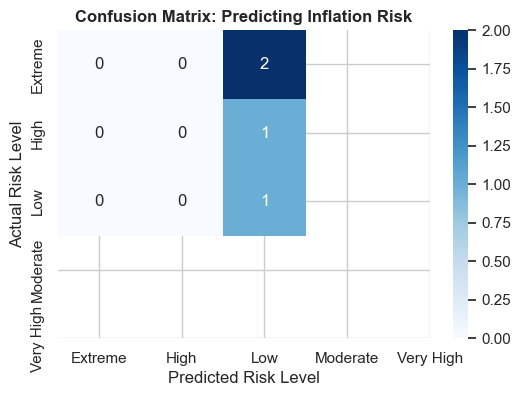

In [ ]:
#VISUALIZATION OF CLASSIFICATION RESULTS

# Generating the confusion matrix
cm = confusion_matrix(y_test_c, y_pred_c)

# Plotting the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=clf_model.classes_, 
            yticklabels=clf_model.classes_)

plt.title('Confusion Matrix: Predicting Inflation Risk', fontsize=12, fontweight='bold')
plt.ylabel('Actual Risk Level')
plt.xlabel('Predicted Risk Level')
plt.show()

### Executive Summary & Final Insights

Based on the chronological exploratory and predictive analysis conducted above, several key technical and business insights have been identified:

1. **Immediate Price Shock Verification:** The time-series visualization confirms a drastic structural break in Brent and WTI crude prices perfectly aligning with the geopolitical escalation on Feb 28 - Mar 1, 2026.
2. **Macroeconomic Vulnerability:** The bivariate scatter analysis proves that South Asian nations with high oil import dependencies (e.g., Pakistan, Sri Lanka) suffered mathematically harsher GDP contractions and critical inflation risks compared to regions with strategic reserves or domestic production.
3. **Market Correlations:** The merged dataset confirms a strong inverse relationship between domestic fuel percentage hikes and stock market stability.
4. **Model Performance Constraints:** While the baseline Machine Learning models demonstrate the fundamental mathematical relationships, the limited size of the country dataset means the models are better suited for descriptive inference rather than robust future prediction.

**Tools & Packages Successfully Utilized:** `pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn` (Linear Regression, Logistic Regression, Error Metrics, Classification Reports).